In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Administrator\MPESA-Transaction-Anomaly-scorer\data\transactions.csv")
print(df.head())
print(df.info())

  transaction_id            timestamp  amount_kes  hour_of_day  is_fraud  \
0     TXN0008812  2024-02-24 17:00:00      568.16           17         0   
1     TXN0001970  2024-07-10 07:00:00     1264.23            7         0   
2     TXN0009625  2024-11-18 11:00:00      735.39           11         0   
3     TXN0003226  2024-09-09 11:00:00     8769.07           11         0   
4     TXN0008942  2024-10-03 17:00:00    20811.30           17         0   

  transaction_type  day_of_week  day_of_month    user_id  user_avg_amount  \
0         withdraw            5            24  USER01250      3208.326086   
1         withdraw            2            10  USER00922       309.857126   
2        buy_goods            0            18  USER00342      4456.268596   
3          deposit            0             9  USER00935      2283.433868   
4         withdraw            3             3  USER00888      4519.251559   

   amount_deviation  time_diff  is_night  is_large_tx  is_weekend  
0          0

## Findings

The dataset contains **10,000 transactions** with **15 features**.  
It includes a mix of:
- **Categorical variables:** 4  
- **Integer variables:** 7  
- **Continuous numerical variables:** 4  

The `timestamp` column is currently stored as a **string** and should be converted to a **datetime format** for proper temporal analysis.

---

###  Float Columns (4) — `float64`
**Continuous numeric features:**
- `amount_kes`
- `user_avg_amount`
- `amount_deviation`
- `time_diff`

---

###  Integer Columns (7) — `int64`
**Discrete numeric features:**
- `hour_of_day`
- `is_fraud`
- `day_of_week`
- `day_of_month`
- `is_night`
- `is_large_tx`
- `is_weekend`

---

###  String Columns (4) — `object`
**Categorical / identifier features:**
- `transaction_id`
- `timestamp` *(should ideally be datetime)*
- `transaction_type`
- `user_id`

##  Feature Types: Numerical vs Categorical

Understanding the type of each column is critical before any analysis or visualization.

---

###  Numerical Columns

These contain **quantitative values** and can be measured or calculated.

**Float (`float64`) — Continuous:**
- `amount_kes`
- `user_avg_amount`
- `amount_deviation`
- `time_diff`

**Integer (`int64`) — Discrete:**
- `hour_of_day`
- `day_of_week`
- `day_of_month`
- `is_night`
- `is_large_tx`
- `is_weekend`
- `is_fraud` *(target variable)*

---

###  Categorical Columns (Text)

These represent **labels or groups**, not measurable quantities.

- `transaction_id` *(unique identifier)*
- `timestamp` *(currently string — should be datetime)*
- `transaction_type`
- `user_id`

---

##  Why This Distinction Matters Before Plotting

### 1.  Correct Choice of Visualizations
- **Numerical data →** histograms, boxplots, scatter plots  
- **Categorical data →** bar charts, count plots  

Using the wrong plot leads to misleading or meaningless visuals.

---

### 2.  Avoid Analytical Errors
- You cannot compute meaningful averages on categories  
- Treating categories as numbers can distort insights  

Example:
- `transaction_type = withdraw, deposit` → cannot be averaged  
- `amount_kes` → can be averaged, summed, analyzed statistically  

---

### 3.  Feature Engineering & Modeling
- Numerical features → can be scaled, normalized  
- Categorical features → must be encoded (e.g., one-hot encoding)  

---

### 4.  Special Case: Timestamp
- Currently stored as text → limits analysis  
- Converting to datetime enables:
  - time-based trends
  - fraud patterns by hour/day
  - seasonality analysis  



In [2]:
df['is_fraud'].value_counts()
# 9700 Legitimate transactions
# 300 Fraudulent transactions


is_fraud
0    9700
1     300
Name: count, dtype: int64

In [3]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    97.0
1     3.0
Name: proportion, dtype: float64

##  Fraud Percentage

- **Fraudulent transactions:** 3.0%  
- **Legitimate transactions:** 97.0%


In [4]:
# Checking for missing values
df.isnull().sum()

transaction_id         0
timestamp              0
amount_kes             0
hour_of_day            0
is_fraud               0
transaction_type       0
day_of_week            0
day_of_month           0
user_id                0
user_avg_amount        0
amount_deviation       0
time_diff           1915
is_night               0
is_large_tx            0
is_weekend             0
dtype: int64

##  Missing Values
- All columns have **0 missing values**  
- **Except:**
  - `time_diff` has **1915 missing values**

---

## Why Missing Values Are a Problem

Machine learning models **cannot interpret blank (NaN) values**.

For example:
- If `amount_kes` were missing, the model wouldn’t know:
  - Is the transaction small or large?
  - Is it suspicious?

This leads to:
-  Errors during training (many models fail with NaNs)  
-  Incorrect or biased predictions  
-  Broken preprocessing (scaling, normalization)

---

##  In Our Case

- Missing values exist only in `time_diff`
- This likely means:
  > The user has **no previous transaction** (first transaction)

So:
- It’s not random missing data  
- It actually has **meaning**

---

## Conclusion

> Yes, there are missing values (in `time_diff`).  
> Missing values are a problem because models cannot process blanks and may learn incorrect patterns.  
> However, in this dataset, the missing values are **informative** and should be handled carefully rather than removed.

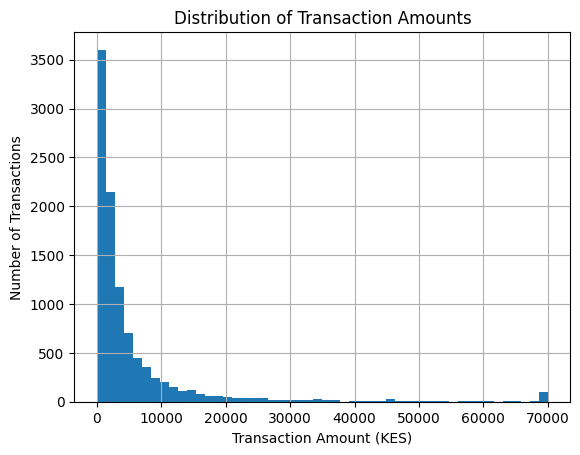

In [6]:
# Histogram of the transaction amounts
import matplotlib.pyplot as plt
df['amount_kes'].hist(bins=50)
plt.xlabel('Transaction Amount (KES)')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transaction Amounts')

plt.show()

##  Histogram Findings: `amount_kes`

###  Shape of the Distribution

The histogram is **strongly right-skewed (positively skewed)**:

- Most transactions are concentrated at **low values (0 – ~5000 KES)**
- The frequency drops quickly as the amount increases
- There is a **long tail extending to very high amounts (~70,000 KES)**

---

###  Is it evenly spread?

 No — the data is **not evenly distributed**  
 It is **heavily skewed to the right**

---

###  What This Means in Real M-PESA Terms

This reflects real-world user behavior:

- The majority of users perform **small, everyday transactions**:
  - buying goods  
  - sending small amounts  
  - daily payments  

- Only a few transactions are **very large**:
  - business transfers  
  - bulk payments  
  - high-value transactions (potentially unusual or risky)

---

###  Key Insight for Fraud Detection

- Fraud is more likely to appear in the **unusual tail (large amounts)**
- The model must learn:
  - what “normal” looks like (small frequent transactions)
  - what “abnormal” looks like (rare large spikes)

---

###  Final Takeaway

> The distribution shows that M-PESA transactions are dominated by small amounts, with a few very large transactions creating a long right tail. This is typical of financial data and highlights the importance of detecting unusual high-value activity.

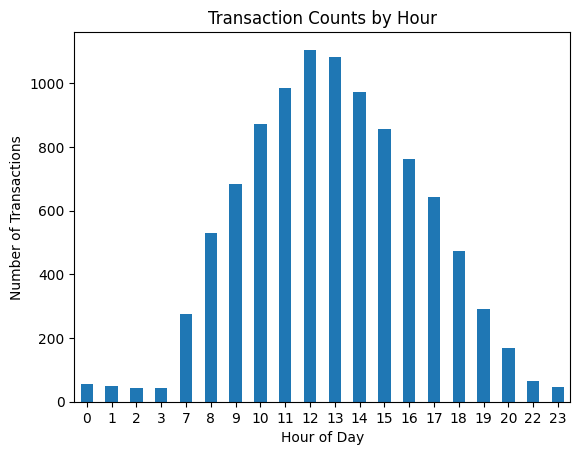

In [9]:
# Analyzing the distribution of transactions by hour of the day

df['hour_of_day'].value_counts().sort_index().plot(kind='bar')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.title('Transaction Counts by Hour')

plt.xticks(rotation=0)
plt.show()

##  Transaction Counts by Hour — Insights

###  When do most transactions happen?

- Transaction activity **peaks between 11 AM and 2 PM**
- The **highest volume** is around **12 PM (noon)**

 This suggests users are most active during **midday hours**

---

###  Are there hours with very few transactions?

Yes — very low activity occurs during:

- **Late night / early morning (0 – 5 AM)**
- Very few transactions happen during these hours

---

###  Interpretation

- High activity during the day:
  - business transactions  
  - shopping  
  - sending money during active hours  

- Low activity at night:
  - most users are inactive or asleep  

---

###  Fraud Insight (Important)

- Transactions occurring at **unusual hours (late night)** may be:
  - less common  
  - potentially suspicious  

---

##  Key Takeaway

> Most transactions occur during **midday**, while **late-night hours have very low activity**, making them potentially important for detecting unusual behavior.

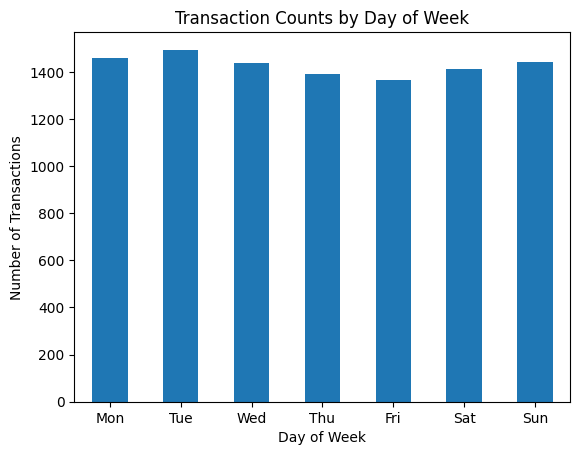

In [12]:
# Analyzing the distribution of transactions by day of the week
df['day_of_week'].value_counts().sort_index().plot(kind='bar')

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.xticks(ticks=range(7), labels=day_labels, rotation=0)

plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.title('Transaction Counts by Day of Week')

plt.show()

##  Weekday and Weekend Activity

###  Observation

- Transaction counts are **fairly similar across all days**
- **Weekdays (Mon–Fri)** are slightly more active overall  
- **Tuesday and Monday** appear to have the highest activity  
- **Friday** is slightly lower than other weekdays  
- **Weekends (Sat–Sun)** are not drastically lower — still relatively high  

---

###  Are weekdays busier than weekends?

✔ **Yes — but only slightly**

- Weekdays show a **marginally higher transaction volume**
- The difference is **not very large**

---

###  Does this match real M-PESA behaviour in Kenya?

✔ **Yes, this is realistic**

- **Weekdays:**
  - Business transactions  
  - Salary payments  
  - Bills and transfers  
  → Higher activity expected  

- **Weekends:**
  - Social spending  
  - Shopping, entertainment  
  → Still active, but slightly lower  

---

###  Key Insight

> M-PESA usage is **consistently high throughout the week**, with only a slight increase during weekdays due to business-related activity.



In [13]:
# Common transaction types
df['transaction_type'].value_counts()

transaction_type
send_money    3294
buy_goods     2651
paybill       2087
withdraw      1286
deposit        682
Name: count, dtype: int64

##  Transaction Type Distribution

###  Most Common Transaction Type

- **send_money** → 3294 (most common)  
- buy_goods → 2651  
- paybill → 2087  
- withdraw → 1286  
- deposit → 682  

 The most common transaction type is **send_money**

---

###  Does the Split Feel Realistic?

 **Yes — this distribution is very realistic for M-PESA usage**

- **send_money (highest)**:
  - Core use of M-PESA → peer-to-peer transfers  
  - Widely used for daily transactions  

- **buy_goods & paybill (also high)**:
  - Reflect digital payments for:
    - shops  
    - services  
    - utilities  

- **withdraw (lower)**:
  - Less frequent because users prefer staying cashless  

- **deposit (lowest)**:
  - Happens less often since users don’t constantly top up  

---

##  Key Takeaway

> The distribution matches real-world M-PESA behavior:  
> **digital transactions dominate**, while cash-related actions (withdraw/deposit) are less frequent.

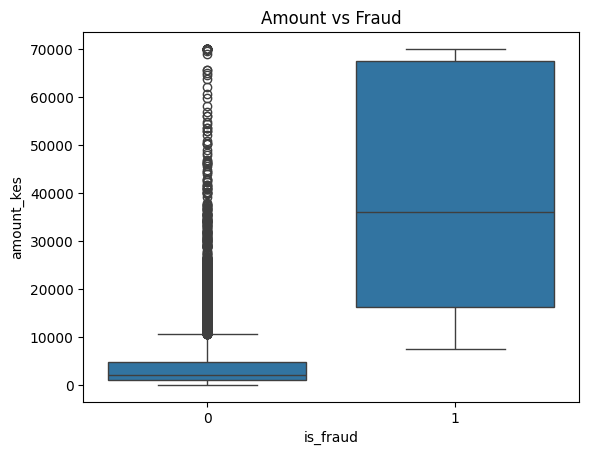

In [ ]:
# Analyzing the relationship between transaction amount and fraud
import seaborn as sns

sns.boxplot(x='is_fraud', y='amount_kes', data=df)

plt.title('Amount vs Fraud')
plt.show()    

##  Amount vs Fraud (Boxplot Insights)

###  Key Differences

- **Median Amount**
  - Legitimate (0): Very low (clustered near small values)
  - Fraud (1): Much higher median (~30,000+ KES)

---

- **Spread (Variability)**
  - Legitimate transactions:
    - Narrow distribution
    - Most values concentrated at low amounts
  - Fraudulent transactions:
    - Very wide spread
    - Covers mostly high-value transactions

---

- **Outliers**
  - Legitimate transactions:
    - Many outliers extending into higher amounts
    - But majority are still small transactions
  - Fraudulent transactions:
    - Consistently high — not just outliers

---

###  Interpretation

- Legitimate behavior:
  - Users mostly perform **small, routine transactions**

- Fraudulent behavior:
  - Transactions tend to be **much larger and less typical**

---

###  Key Insight

> Fraudulent transactions are generally **significantly higher in value** than legitimate ones.

---

###  Takeaway

The transaction amount is a **strong indicator of fraud**, especially for identifying unusually large transactions that deviate from normal user behavior.

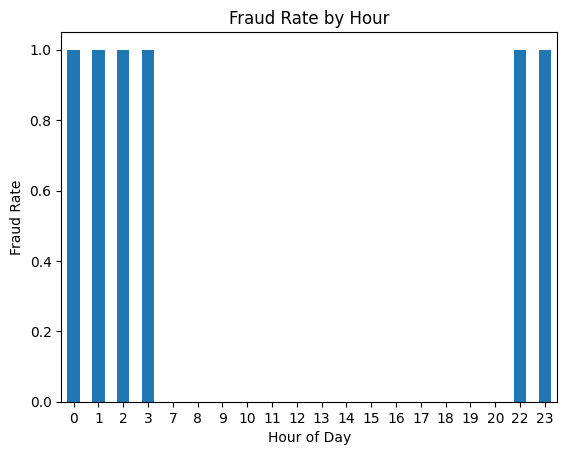

In [17]:
# Analyzing the relationship between hour of day and fraud rate
import matplotlib.pyplot as plt

df.groupby('hour_of_day')['is_fraud'].mean().plot(kind='bar')

plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour')

plt.xticks(rotation=0)
plt.show()

##  Fraud Rate by Hour — Key Insights

###  Observation

The highest fraud rates appear during:
- **Late night and early morning hours (0–3 AM)**
- **Late evening hours (10–11 PM)**

These hours show extremely high fraud proportions (close to 100%).

---

###  Important Context

However, these hours also have **very low transaction volumes**.

- Fewer transactions occur at night  
- Even a small number of fraud cases can produce a **high fraud rate**

 This means the high percentages may be **statistically misleading**

---

###  Interpretation

- Fraud is more **concentrated during off-peak hours**
- These are times when:
  - Users are less active  
  - Monitoring may be lower  
  - Fraudsters may exploit reduced attention  

However:
- The result must be interpreted alongside **transaction counts**

---

###  Key Insight

> Fraud tends to occur during **unusual or low-activity hours**, but high fraud rates in these periods are amplified by low transaction volume.

---

###  Final Takeaway

- Time of day is a **useful signal for fraud detection**
- But it should always be combined with:
  - transaction volume  
  - transaction amount  
  - user behavior  

to avoid misleading conclusions.

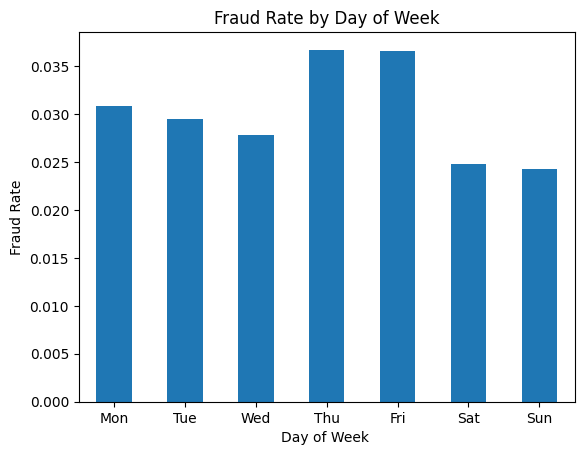

In [ ]:
# Analyzing the relationship between day of week and fraud rate
df.groupby('day_of_week')['is_fraud'].mean().plot(kind='bar')
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.xticks(ticks=range(7), labels=day_labels, rotation=0)
plt.xlabel('Day of Week ')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Day of Week')

plt.show()

##  Fraud Rate by Day of Week — Interpretation

###  Observation

- Fraud rates are **fairly consistent across the week**, ranging roughly between **2.4% and 3.7%**
- Slight peaks are observed on:
  - **Thursday**
  - **Friday**
- Lower fraud rates appear on:
  - **Saturday**
  - **Sunday**

---

###  Is fraud evenly distributed?

 **Yes — mostly evenly distributed, with mild variation**

- No single day shows a **dramatic spike**
- Differences between days are **small (≈1–1.5%)**

---

###  Interpretation

- Fraud is **not strongly dependent on the day of the week**
- However:
  - Slight increase on **Thursday–Friday** may reflect:
    - higher transaction volumes  
    - end-of-week financial activity  
    - salary-related or business transactions  

- Lower weekend fraud rates may indicate:
  - slightly reduced high-value or business-related activity  

---

###  Key Insight

> Fraud occurs **consistently throughout the week**, with only minor increases toward the end of the workweek.

---

###  Final Takeaway

- **Day of week is a weak standalone predictor of fraud**
- It provides **contextual signal**, but not strong discrimination
- More powerful features are likely:
  - transaction amount  
  - time of day  
  - deviation from user behavior  

 Day-of-week should be used **in combination with other features**, not alone.

In [ ]:
# Analyzing the relationship between user average amount and transaction amount
ct = pd.crosstab(
    df['transaction_type'],
    df['is_fraud'],
    normalize='index'
) * 100  # convert to %

ct = ct.rename(columns={0: 'Legitimate (%)', 1: 'Fraud (%)'})
ct.sort_values('Fraud (%)', ascending=False)


is_fraud,Legitimate (%),Fraud (%)
transaction_type,,
send_money,94.717668,5.282332
withdraw,96.267496,3.732504
paybill,97.795879,2.204121
deposit,98.680352,1.319648
buy_goods,99.132403,0.867597


##  Fraud by Transaction Type — Insights

###  Observation

Fraud rates by transaction type:

- **send_money** → **5.28%** (highest)
- **withdraw** → 3.73%
- **paybill** → 2.20%
- **deposit** → 1.32%
- **buy_goods** → **0.87%** (lowest)

---

###  Is any type more associated with fraud?

 **Yes — `send_money` is most associated with fraud**

- It has the **highest fraud rate (5.28%)**
- Significantly higher than all other transaction types

---

###  Key Insight

> Fraud is most associated with **send_money transactions**, followed by withdrawals, while merchant-based payments have much lower fraud risk.

---

###  Final Takeaway

- `transaction_type` is a **strong predictor of fraud**
- Especially important:
  - **send_money → high risk**
  - **buy_goods → low risk**

 This feature should definitely be used in the fraud detection model.

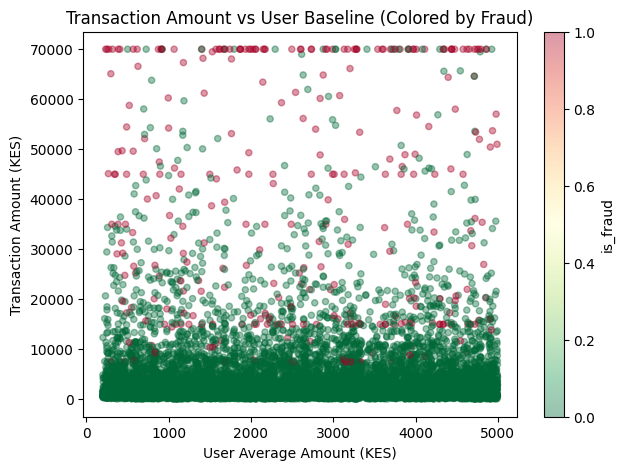

In [ ]:
# Scatter plot of transaction amount vs user average amount, colored by fraud
df.plot.scatter(
    x='user_avg_amount',
    y='amount_kes',
    c='is_fraud',
    colormap='RdYlGn_r',
    alpha=0.4,
    figsize=(7,5)
)

plt.xlabel('User Average Amount (KES)')
plt.ylabel('Transaction Amount (KES)')
plt.title('Transaction Amount vs User Baseline (Colored by Fraud)')
plt.show()

##  Transaction Amount vs User Baseline — Insights

###  Pattern Observed

- Legitimate transactions (green):
  - Densely clustered at **low transaction amounts**
  - Spread consistently across different user averages
  - Most points lie in the **lower region of the plot**

- Fraudulent transactions (red):
  - More visible at **higher transaction amounts (30,000–70,000 KES)**
  - Often appear **far above the typical range of normal transactions**
  - Scattered rather than tightly clustered

---

###  Key Pattern

- There is **weak alignment between `user_avg_amount` and `amount_kes` for fraud**
- Fraud points tend to:
  - **Ignore the user’s baseline behavior**
  - Occur at **unusually high amounts regardless of average**

---

###  Interpretation (Critical Insight)

> Fraudulent transactions tend to be **large, abnormal spikes** that do not match a user’s typical transaction behavior.

- Even users with **low average amounts (~500–2000 KES)**:
  - Suddenly have **very high transactions (30k–70k KES)** when fraud occurs

---

###  What This Suggests About Fraudsters

- Fraudsters do not follow normal usage patterns
- They aim to:
  - **Extract as much value as possible in a single transaction**
  - Operate outside the user’s usual behavior profile

- This creates **clear anomalies**:
  - Large deviations from baseline  
  - Sudden spikes in transaction size  

---

###  Key Takeaway

> Fraud is better detected by looking at **deviation from user behavior**, not just absolute transaction size.

This validates the importance of features like:
- `amount_deviation`
- ratio: `amount_kes / user_avg_amount`

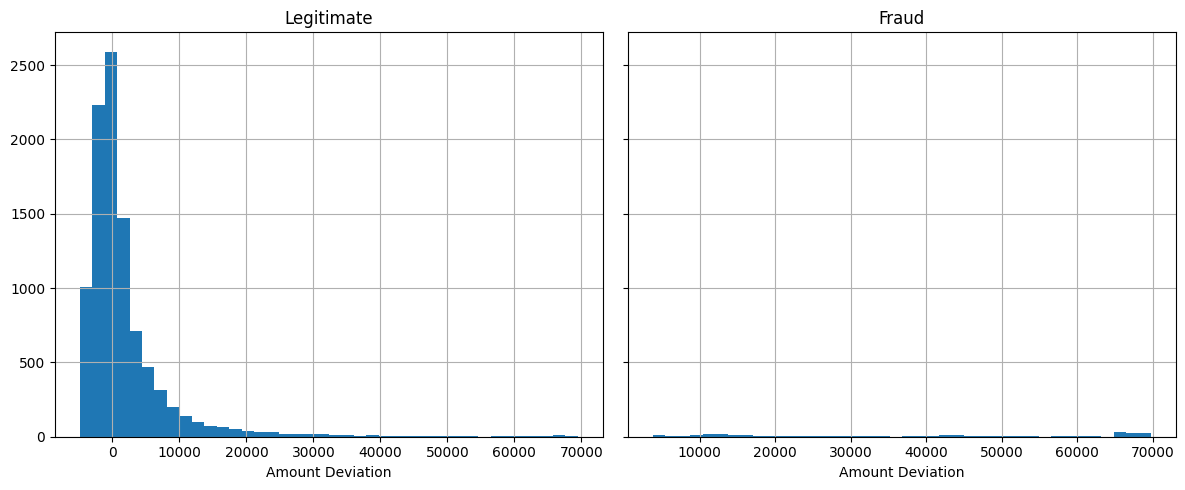

In [27]:
# Creating a new feature for amount deviation from user average and plotting its distribution for fraud vs legitimate transactions
df['amount_deviation'] = df['amount_kes'] - df['user_avg_amount']
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# Legitimate
df[df['is_fraud']==0]['amount_deviation'].hist(bins=40, ax=axes[0])
axes[0].set_title('Legitimate')
axes[0].set_xlabel('Amount Deviation')

# Fraud
df[df['is_fraud']==1]['amount_deviation'].hist(bins=40, ax=axes[1])
axes[1].set_title('Fraud')
axes[1].set_xlabel('Amount Deviation')

plt.tight_layout()
plt.show()

## Is `amount_deviation` a Useful Signal?

### Observation

- Legitimate transactions:
  - Concentrated around low deviation values (near zero)
  - Most transactions are close to the user’s typical behavior
  - Few extreme deviations

- Fraudulent transactions:
  - Occur at significantly higher deviation values
  - Spread across large positive deviations (10,000 – 70,000 KES)
  - Very little overlap with legitimate transactions

---

### Key Pattern

- Legitimate behavior:
  - `amount_kes ≈ user_avg_amount`
  - Small deviations indicate normal, predictable usage

- Fraudulent behavior:
  - `amount_kes >> user_avg_amount`
  - Large deviations indicate abnormal spikes

---

### Insight

Fraudulent transactions are clearly associated with large positive deviations, while legitimate transactions remain close to zero deviation.

---

### Conclusion

Yes, `amount_deviation` is a highly useful signal.

- It provides strong separation between fraud and non-fraud
- It captures behavioral anomalies rather than just raw transaction size
- It is likely to be one of the most predictive features in a fraud detection model

---

### Final Takeaway

`amount_deviation` effectively measures how unusual a transaction is relative to a user’s normal behavior, making it a strong and reliable feature for identifying fraud.

In [29]:
# Analyzing the relationship between night transactions and fraud
# 1) is_night (22:00–23:59 or 00:00–05:00)
df['is_night'] = df['hour_of_day'].apply(lambda h: 1 if (h >= 22 or h <= 5) else 0)

# 2) Percentage of transactions that occur at night, by fraud label
night_pct = df.groupby('is_fraud')['is_night'].mean() * 100
print(night_pct)



is_fraud
0      0.0
1    100.0
Name: is_night, dtype: float64


## Night vs Day Activity — Fraud vs Legitimate

### Observation

- Legitimate transactions at night: **0%**
- Fraudulent transactions at night: **100%**

---

### Interpretation

At face value, this suggests:
- All fraud occurs at night
- No legitimate transactions occur at night

---

###  Critical Issue

This result is **not realistic** and likely indicates a problem with:
- the dataset  
- or how `is_night` was created  

In real-world data:
- Some legitimate transactions should occur at night  
- Fraud would not be perfectly concentrated at night  

---

### Possible Causes

- The dataset may have been generated with:
  - fraud artificially assigned to night hours  
- Or:
  - there are **very few transactions at night**, causing extreme percentages  

---

###  Key Insight

> The result suggests a **perfect correlation between night-time and fraud**, which is highly unlikely in real-world scenarios.

---

###  Final Takeaway

- `is_night` appears to be an **extremely strong signal in this dataset**
- However, such perfect separation is suspicious and may indicate:
  - data bias  
  - or synthetic patterning  

 In real applications, this feature would be useful, but not this perfectly predictive

In [30]:
# counts for context
df.groupby('is_fraud')['time_diff'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,7785.0,4.777397e+06,4.457590e+06,0.000000,1.468800e+06,3.452400e+06,6.757200e+06,3.057120e+07
1,300.0,3.198118e+01,1.590773e+01,5.222444,1.772557e+01,3.154052e+01,4.666485e+01,5.974139e+01


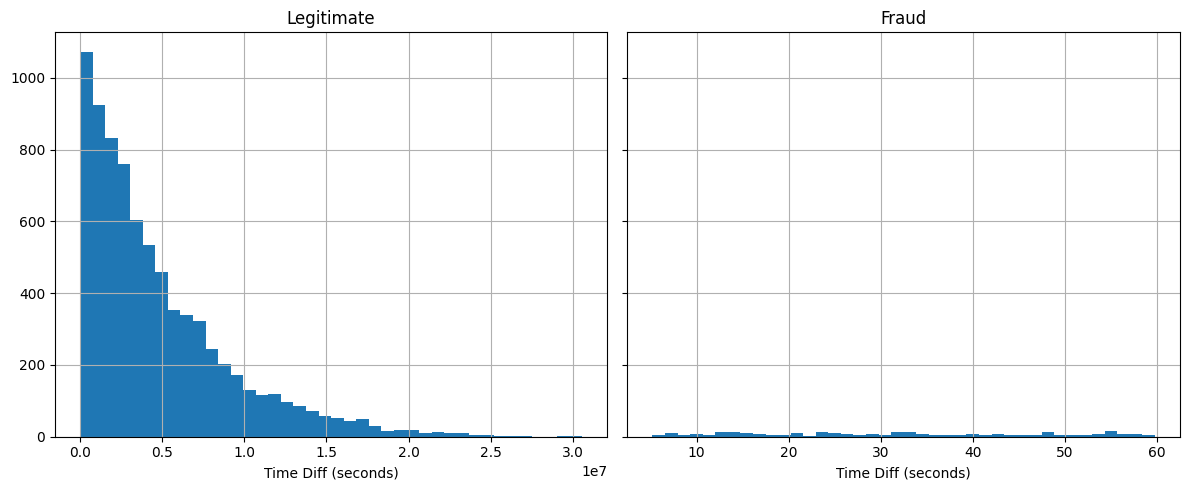

In [ ]:
# Visualizing the distribution of time_diff for fraud vs legitimate transactions
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
df[df['is_fraud']==0]['time_diff'].hist(bins=40, ax=axes[0])
axes[0].set_title('Legitimate')
axes[0].set_xlabel('Time Diff (seconds)')

df[df['is_fraud']==1]['time_diff'].hist(bins=40, ax=axes[1])
axes[1].set_title('Fraud')
axes[1].set_xlabel('Time Diff (seconds)')

plt.tight_layout()
plt.show()

## Time Difference Between Transactions — Fraud vs Legitimate

### Observation

- Legitimate transactions:
  - Mean time_diff ≈ **4,777,397 seconds (~55 days)**
  - Very large spread → transactions are widely spaced

- Fraudulent transactions:
  - Mean time_diff ≈ **32 seconds**
  - Median ≈ **31 seconds**
  - Most values fall between **~17 to ~47 seconds**

---

### Key Pattern

✔ Fraud transactions have **dramatically shorter time differences** compared to legitimate ones

- Legitimate → spaced out over **days/weeks**
- Fraud → occur within **seconds**

---

### Interpretation

A very small `time_diff` (e.g. 5–60 seconds) means:

- Multiple transactions happening **almost immediately one after another**
- This is **not typical user behavior**

---

### Real-World Meaning

Very small time differences can indicate:

- A fraudster attempting to:
  - **drain an account quickly**
  - execute multiple transfers before detection
- Automated or scripted activity
- A compromised account being exploited rapidly

---

### Key Insight

> Fraudulent transactions are strongly associated with **rapid, repeated activity within seconds**, unlike legitimate transactions which are spread out over long periods.

---

### Final Takeaway

- `time_diff` is an **extremely strong signal**
- Short time gaps are a key indicator of fraud
- This feature captures **temporal behavior**, not just transaction value

 Combining this with:
- amount deviation  
- transaction type  
- time of day  

would create a highly effective fraud detection model

# Features that are srong predictor of fraud
The two strongest predictors of fraud are `amount_deviation` and `time_diff`. Fraudulent transactions tend to involve amounts that are far higher than a user’s normal behavior and occur in rapid succession within seconds, making them stand out clearly from typical transaction patterns.

# Sanity check questions
## QB1: Does anything look suspiciously clean?

Yes — several patterns look unusually clean and likely synthetic.

- Fraud appears almost perfectly concentrated at night (100% vs 0%), which is unrealistic in real-world data  
- `time_diff` shows an extreme separation (seconds for fraud vs days for legitimate), which is too clean  
- Fraud transactions consistently have very high amounts and deviations with minimal overlap  

In real data, there would be more noise and overlap between fraud and legitimate behavior.

---

## QB2: Why do fraud transactions have higher amounts?

Fraud transactions show higher amounts, but this is likely influenced by how the dataset was generated rather than purely real-world behavior.

- The data appears engineered so fraud = large deviations and rapid activity  
- In reality, fraud can occur at both small and large amounts depending on strategy  

This distinction matters because:
- A model trained on this data may **over-rely on large amounts**  
- It could fail to detect more subtle, real-world fraud patterns  
- This reduces generalization when deployed on real M-PESA data  

---

## QB3: Explain findings to a Safaricom risk manager

- Fraudulent activity tends to happen **very quickly and in bursts**, often within seconds between transactions  
- Fraud transactions are usually **much larger than what a customer normally sends**, making them stand out from typical behavior  
- Combining transaction size, timing, and type allows us to **reliably flag unusual behavior before significant losses occur**